# Nifty 50 Stock Market Analysis (2000-2024)
## Exploratory Data Analysis using Python, Pandas, Matplotlib & Seaborn

**Objective:** Analyze 24 years of Nifty 50 data to identify trends, volatility patterns, and yearly performance insights.

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Key Finding:** Nifty 50 grew 1260% over 24 years — from 1592 in 2000 to 21666 in 2024

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
#load the data
df=pd.read_csv("NIFTY 50.csv")
print("shape:",df.shape)
print("\nFirst 5 rows:")
df.head()

shape: (5970, 8)

First 5 rows:


,Date,Open,High,Low,Close,P/E,P/B,Div Yield %
0,2000-01-03,1482.15,1592.90,1482.15,1592.2,25.91,4.63,0.95
1,2000-01-04,1594.40,1641.95,1594.40,1638.7,26.67,4.76,0.92
2,2000-01-05,1634.55,1635.50,1555.05,1595.8,25.97,4.64,0.95
3,2000-01-06,1595.80,1639.00,1595.80,1617.6,26.32,4.70,0.94
4,2000-01-07,1616.60,1628.25,1597.20,1613.3,26.25,4.69,0.94


In [4]:
#Understanding Data
print("column names:",df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\n Basic statitics:")
df.describe()


column names: ['Date', 'Open', 'High', 'Low', 'Close', 'P/E', 'P/B', 'Div Yield %']

Data types:
Date            object
Open           float64
High           float64
Low            float64
Close          float64
P/E            float64
P/B            float64
Div Yield %     object
dtype: object

 Basic statitics:


,Open,High,Low,Close,P/E,P/B
count,5970.000000,5970.000000,5970.000000,5970.00000,5970.000000,5970.000000
mean,6907.663819,6949.017027,6856.590109,6903.95376,20.907717,3.621576
std,5118.079883,5134.187769,5091.789342,5114.08714,4.943233,0.778840
min,853.000000,877.000000,849.950000,854.20000,10.680000,1.920000
25%,2651.812500,2693.837500,2613.112500,2654.60000,17.662500,3.090000
50%,5561.475000,5598.300000,5513.350000,5555.15000,20.710000,3.530000
75%,10060.975000,10109.512500,10001.287500,10045.98750,23.430000,4.090000
max,21751.350000,21834.350000,21680.850000,21778.70000,42.000000,6.550000


In [5]:
#Fixing The Date Column
df["Date"]=pd.to_datetime(df["Date"])
print("Date column type now:",df.dtypes["Date"])
print("Date range:",df["Date"].min(),"to",df["Date"].max())

Date column type now: datetime64[ns]
Date range: 2000-01-03 00:00:00 to 2024-01-02 00:00:00


In [6]:
#Checking For Missing Values
print("missing values in each column:")
print(df.isnull().sum())

missing values in each column:
Date           0
Open           0
High           0
Low            0
Close          0
P/E            0
P/B            0
Div Yield %    0
dtype: int64


In [7]:
#Seting Date As Index
df.set_index("Date",inplace=True)
print("Index set to place successfully!")
df.head()

Index set to place successfully!


,Open,High,Low,Close,P/E,P/B,Div Yield %
Date,,,,,,,
2000-01-03,1482.15,1592.90,1482.15,1592.2,25.91,4.63,0.95
2000-01-04,1594.40,1641.95,1594.40,1638.7,26.67,4.76,0.92
2000-01-05,1634.55,1635.50,1555.05,1595.8,25.97,4.64,0.95
2000-01-06,1595.80,1639.00,1595.80,1617.6,26.32,4.70,0.94
2000-01-07,1616.60,1628.25,1597.20,1613.3,26.25,4.69,0.94


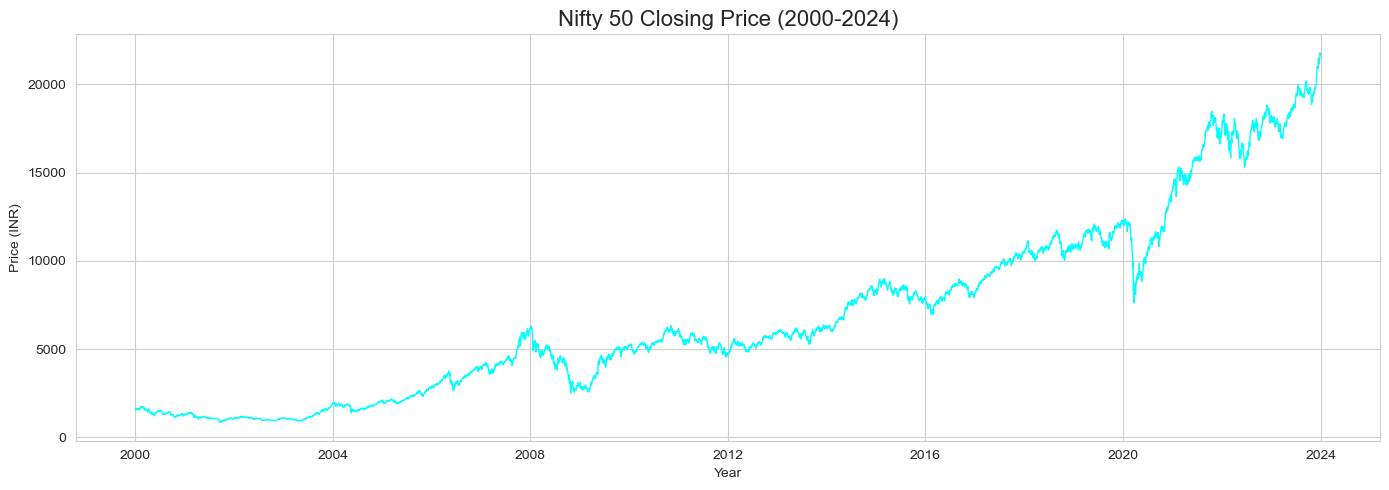

In [8]:
#First Plot: Closing Price Trend over 24 years
plt.figure(figsize=(14,5))
plt.plot(df['Close'], color='cyan', linewidth=1)
plt.title('Nifty 50 Closing Price (2000-2024)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_12428\4087560751.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_avg.index, y=yearly_avg.values, palette='Blues_d')


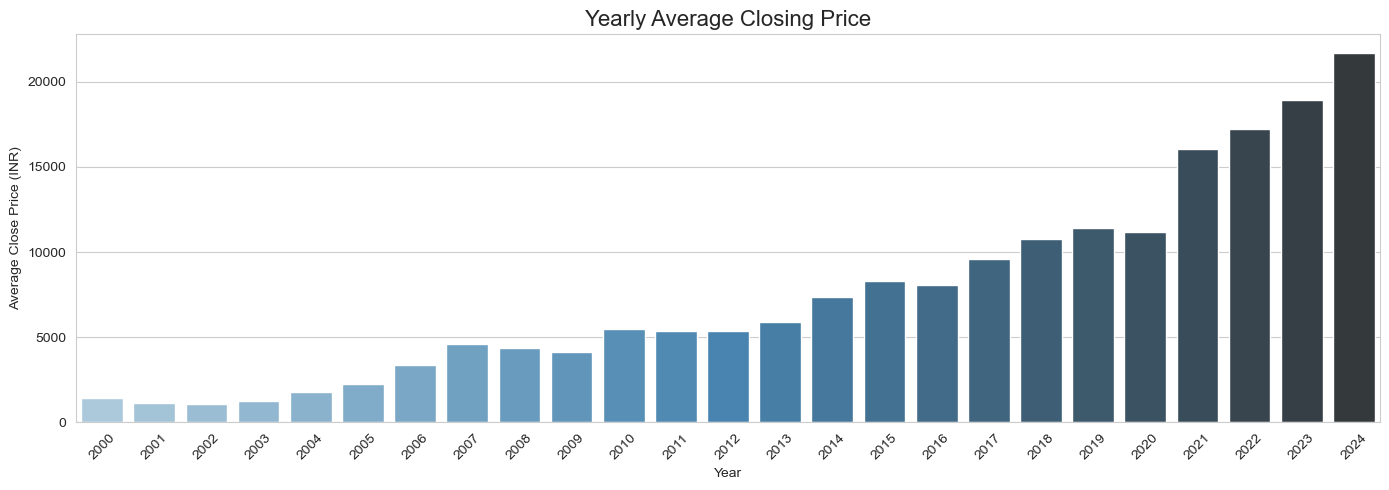

In [9]:
# Yearly Average Closing Price
df['Year'] = df.index.year

yearly_avg = df.groupby('Year')['Close'].mean()

plt.figure(figsize=(14,5))
sns.barplot(x=yearly_avg.index, y=yearly_avg.values, palette='Blues_d')
plt.title('Yearly Average Closing Price', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Average Close Price (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

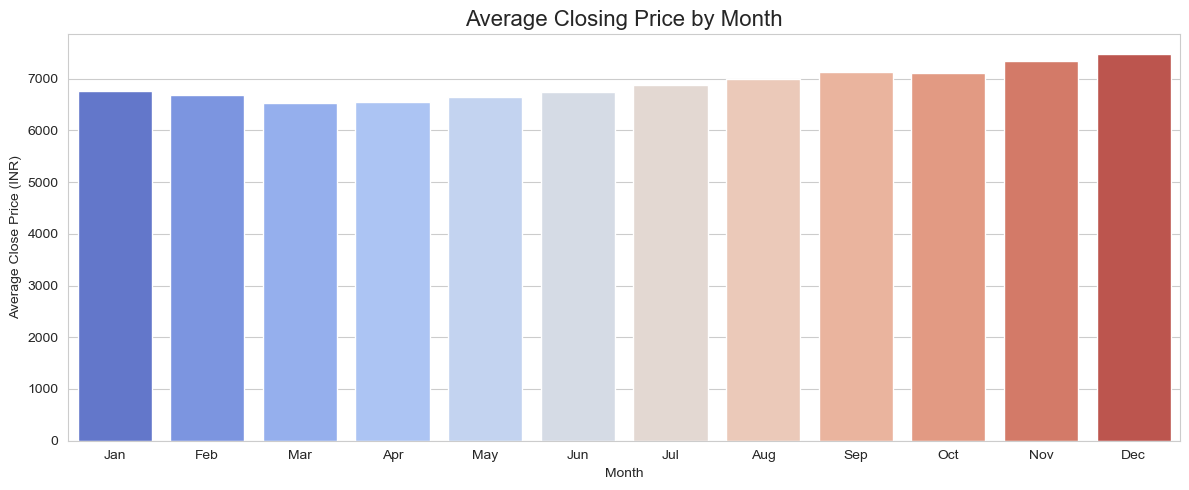

In [10]:
#Monthly Average (Which month is best for Nifty?)
df['Month'] = df.index.month

monthly_avg = df.groupby('Month')['Close'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,5))
sns.barplot(x=month_names, y=monthly_avg.values, hue=month_names, palette='coolwarm', legend=False)
plt.title('Average Closing Price by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Close Price (INR)')
plt.tight_layout()
plt.show()


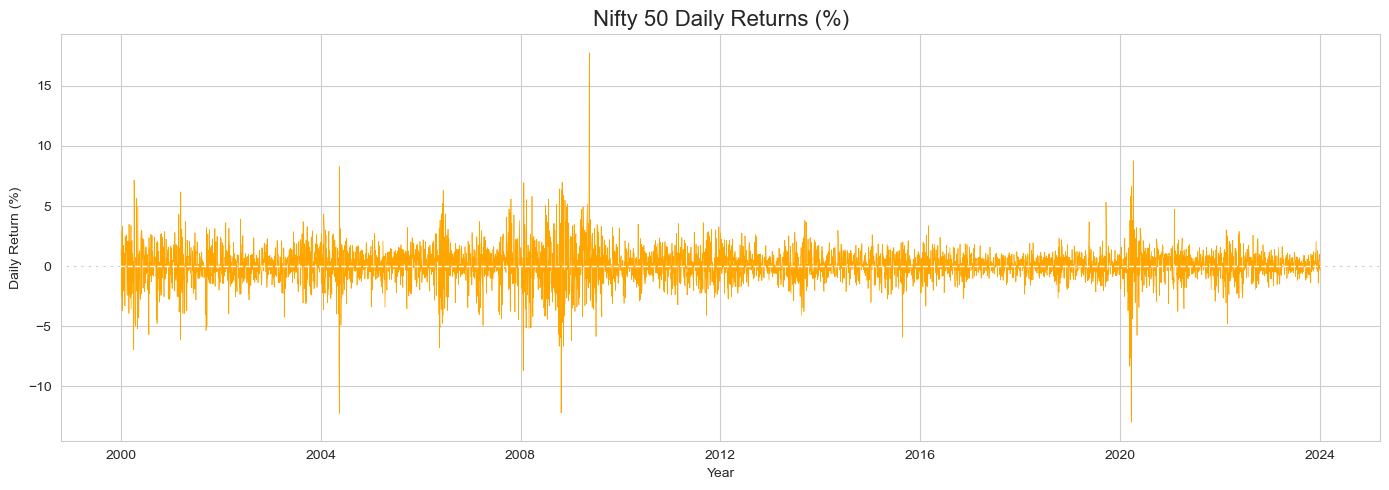

In [11]:
#Daily Returns (How much does Nifty move each day?)
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(14,5))
plt.plot(df['Daily_Return'], color='orange', linewidth=0.5)
plt.title('Nifty 50 Daily Returns (%)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='white', linewidth=1, linestyle='--')
plt.tight_layout()
plt.show()

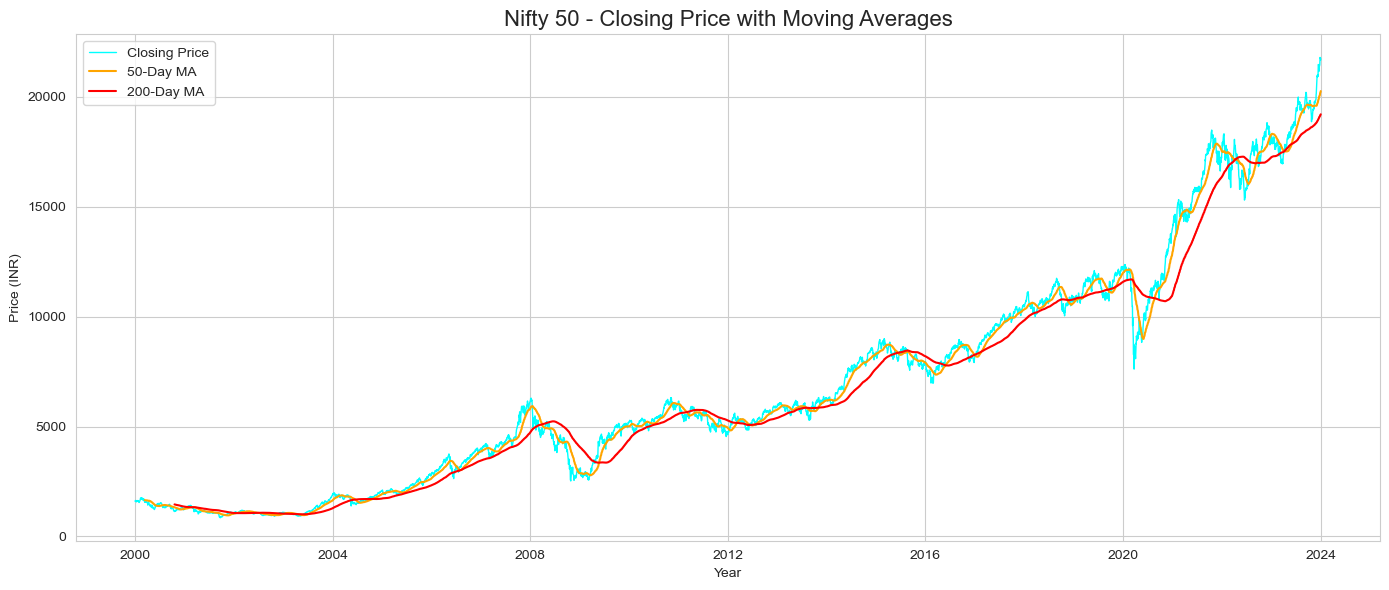

In [12]:
# Moving Averages

df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Close'], color='cyan', linewidth=1, label='Closing Price')
plt.plot(df['MA_50'], color='orange', linewidth=1.5, label='50-Day MA')
plt.plot(df['MA_200'], color='red', linewidth=1.5, label='200-Day MA')
plt.title('Nifty 50 - Closing Price with Moving Averages', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

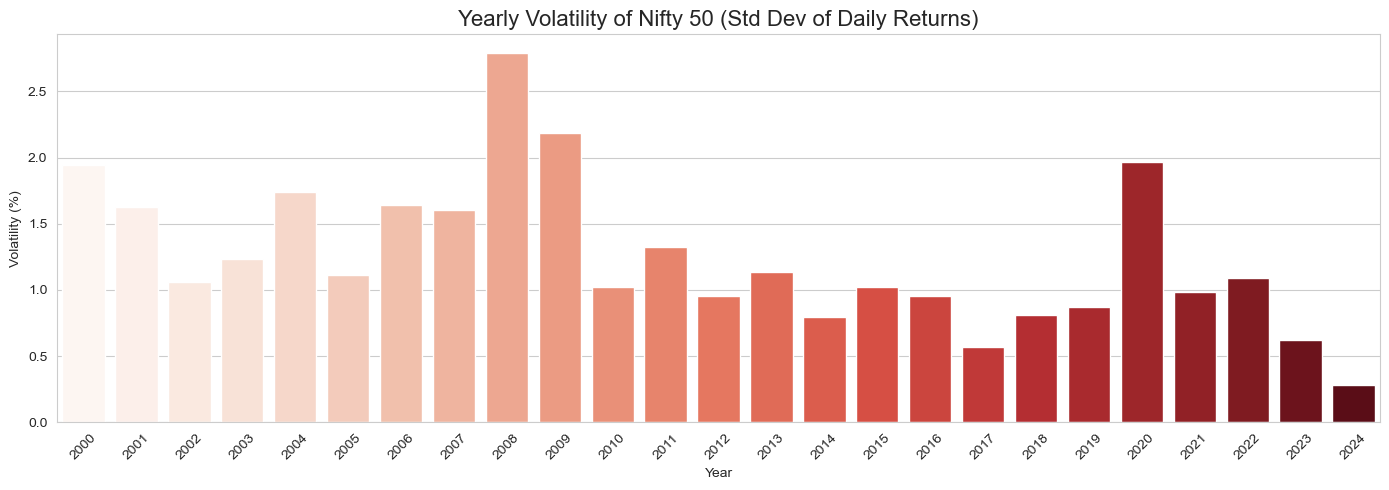

In [13]:
#Volatility Analysis 
yearly_volatility = df['Daily_Return'].groupby(df.index.year).std()

plt.figure(figsize=(14,5))
sns.barplot(x=yearly_volatility.index, y=yearly_volatility.values, 
            hue=yearly_volatility.index, palette='Reds', legend=False)
plt.title('Yearly Volatility of Nifty 50 (Std Dev of Daily Returns)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Volatility (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

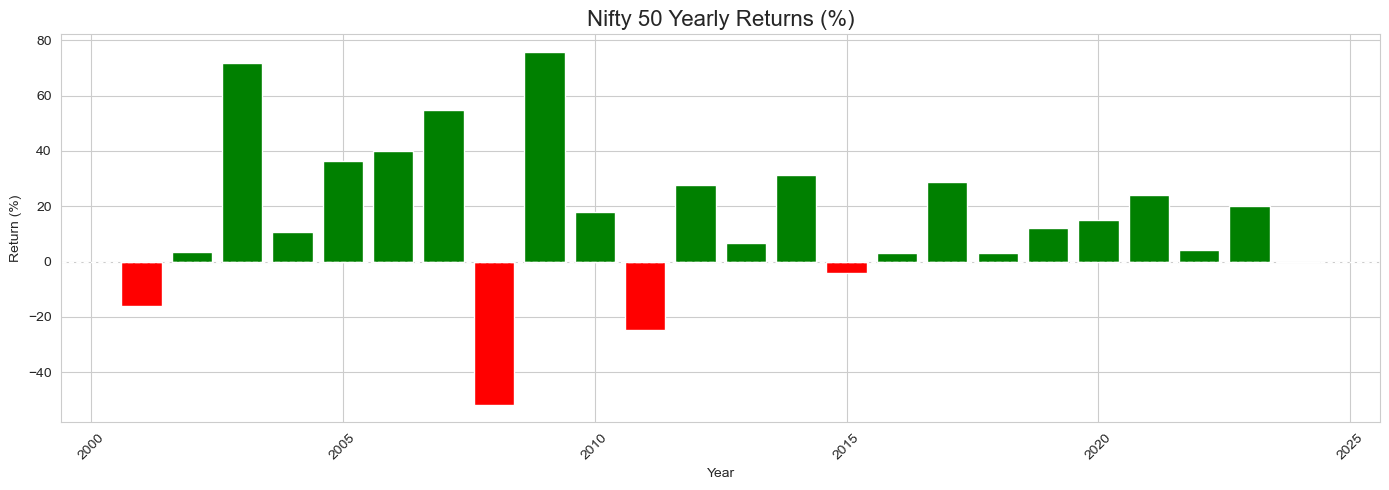

In [14]:
# Best and Worst Years
yearly_return = df['Close'].resample('YE').last().pct_change() * 100
yearly_return = yearly_return.dropna()

colors = ['green' if x > 0 else 'red' for x in yearly_return.values]

plt.figure(figsize=(14,5))
plt.bar(yearly_return.index.year, yearly_return.values, color=colors)
plt.title('Nifty 50 Yearly Returns (%)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Return (%)')
plt.axhline(0, color='white', linewidth=1, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

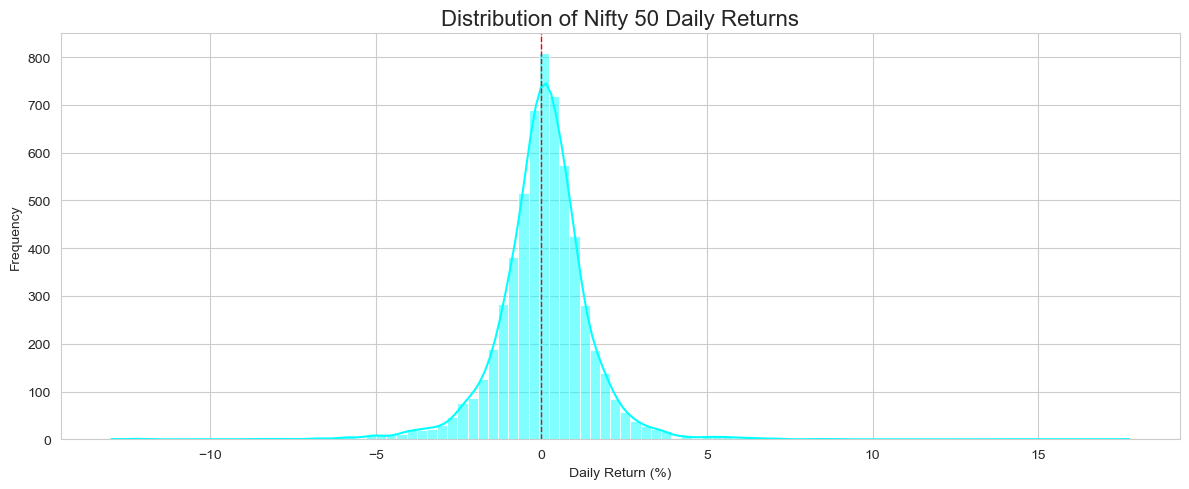

In [15]:
# Distribution of Daily Returns
plt.figure(figsize=(12,5))
sns.histplot(df['Daily_Return'].dropna(), bins=100, color='cyan', kde=True)
plt.title('Distribution of Nifty 50 Daily Returns', fontsize=16)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [16]:
#Insights Summary
print("=" * 50)
print("NIFTY 50 EDA - KEY INSIGHTS")
print("=" * 50)

print(f"\n1. Dataset spans from 2000 to 2024 — 24 years of data ({len(df)} trading days)")

best_year = yearly_return.idxmax().year
worst_year = yearly_return.idxmin().year
print(f"\n2. Best year: {best_year} with {yearly_return.max():.1f}% return")
print(f"3. Worst year: {worst_year} with {yearly_return.min():.1f}% return")

print(f"\n4. Nifty grew from {df['Close'].iloc[0]:.0f} in 2000 to {df['Close'].iloc[-1]:.0f} in 2024")

growth = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0]) * 100
print(f"5. Total growth over 24 years: {growth:.1f}%")

most_volatile = yearly_volatility.idxmax()
print(f"\n6. Most volatile year: {most_volatile} (2008 financial crisis / COVID)")

avg_daily = df['Daily_Return'].mean()
print(f"\n7. Average daily return: {avg_daily:.4f}%")
print(f"8. Daily returns follow a Normal Distribution — most moves within -1% to +1%")
print(f"\n9. Golden Cross pattern visible post 2020 — strongest bull run in Nifty history")
print(f"10. Market gave positive returns in majority of years — long term investing works")
print("\n" + "=" * 50)

NIFTY 50 EDA - KEY INSIGHTS

1. Dataset spans from 2000 to 2024 — 24 years of data (5970 trading days)

2. Best year: 2009 with 75.8% return
3. Worst year: 2008 with -51.8% return

4. Nifty grew from 1592 in 2000 to 21666 in 2024
5. Total growth over 24 years: 1260.7%

6. Most volatile year: 2008 (2008 financial crisis / COVID)

7. Average daily return: 0.0536%
8. Daily returns follow a Normal Distribution — most moves within -1% to +1%

9. Golden Cross pattern visible post 2020 — strongest bull run in Nifty history
10. Market gave positive returns in majority of years — long term investing works

